In [6]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_parquet

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import statsmodels.formula.api as smf
from scipy import stats





Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [11]:
run_id_start = 20000

# tot_viz_df = pd.DataFrame()
# for idx, lang in enumerate(list(CONSTANTS.COGNITIVE_COMPLEXITY_SUPPORTED_LANGS.keys())):
lang = 'python'
idx = 0
print(f'[visualizing....] start visualizing {lang} language')
output_dir = create_dir('./fig/')
src_dir = f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/run_id_{run_id_start+idx}'

option_dict = load_json(f"{src_dir}/data/option.json")
std_date = Date_Setting[option_dict['year_range']]['std_date']

origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])

df = read_complexity_jsonl(option_dict)
# df = calculate_cyclomatic_complexity(df, "sum")
df['cyclomatic_complexity'] = np.log(df['cyclomatic_complexity']+1)

viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'cyclomatic_complexity']]
viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- std_date).dt.days/7)
viz_df = (viz_df.groupby('rel_week', as_index=False)['cyclomatic_complexity'].mean())


[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:12<00:00,  5.17it/s]


TTLibError: not enough 'glyf' table data

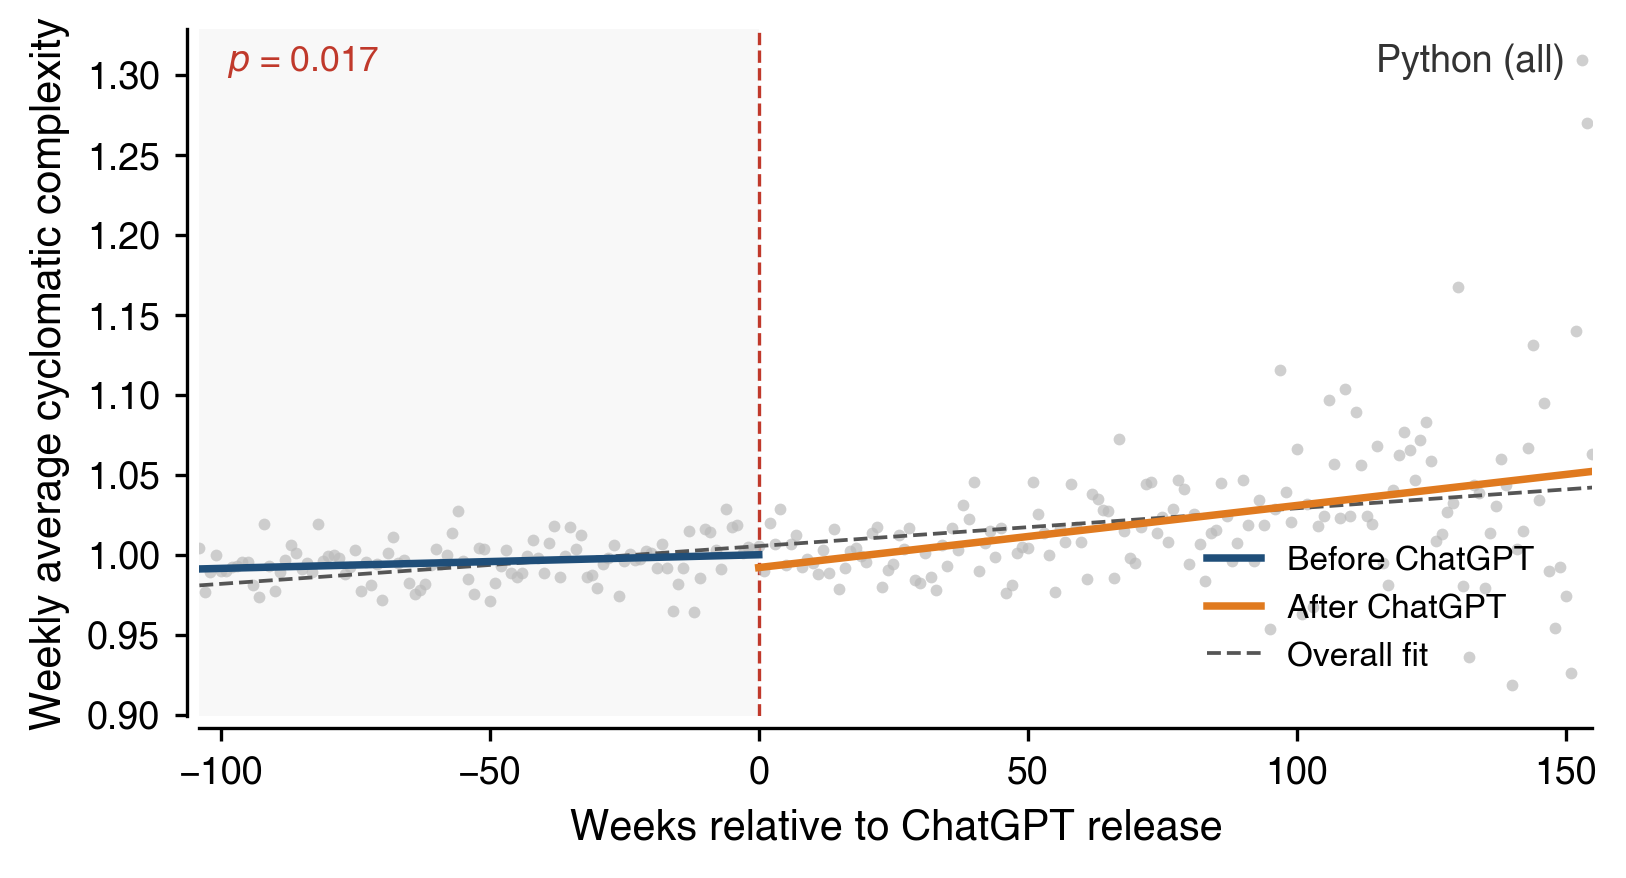

In [13]:
"""
Science-style segmented regression (single panel) — 통합 팔레트
Before/After ChatGPT 두 시기의 선형 추세 + Overall fit + Chow test p-value
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from scipy.stats import f as f_dist

# ============================================================
# 공통 팔레트 (다른 figure들과 통일)
# ============================================================
PALETTE = {
    'primary':    '#1f4e79',   # Before
    'primary_lt': '#A9CCE3',
    'accent':     '#E07A1F',   # After
    'event':      '#C0392B',   # Event line / p-value
    'neutral':    '#555555',   # Overall fit
    'point':      '#BBBBBB',   # 산점도 점
    'bg_pre':     '#F2F2F2',
}

# ============================================================
# 1. 데이터 (본인 데이터로 교체)
# ============================================================
# df = pd.read_csv('your_data.csv')   # rel_week, cyclomatic 컬럼

# --- 예시 더미 ---

df = pd.DataFrame({
    'rel_week':   list(viz_df['rel_week']),
    'cyclomatic': list(viz_df['cyclomatic_complexity'])
})
# -----------------------

TIME_COL  = 'rel_week'
VALUE_COL = 'cyclomatic'
XLABEL    = 'Weeks relative to ChatGPT release'
YLABEL    = 'Weekly average cyclomatic complexity'
GROUP_LBL = 'Python (all)'         # 우상단에 작게 표시. None 가능

OUT_PNG = 'figure_complexity_seg.png'
OUT_PDF = 'figure_complexity_seg.pdf'

# ============================================================
# 2. 저널 rcParams
# ============================================================
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.linewidth': 0.8,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# ============================================================
# 3. Chow test (segmented vs single)
# ============================================================
def chow_test(x, y, break_point=0):
    x = np.asarray(x); y = np.asarray(y)
    pre  = x <  break_point
    post = x >= break_point
    n = len(x); k = 2

    s_all, i_all, *_ = stats.linregress(x, y)
    rss_pooled = np.sum((y - (s_all*x + i_all))**2)

    s1, i1, *_ = stats.linregress(x[pre],  y[pre])
    s2, i2, *_ = stats.linregress(x[post], y[post])
    rss_seg = (np.sum((y[pre]  - (s1*x[pre]  + i1))**2) +
               np.sum((y[post] - (s2*x[post] + i2))**2))

    F = ((rss_pooled - rss_seg) / k) / (rss_seg / (n - 2*k))
    p = 1 - f_dist.cdf(F, k, n - 2*k)
    return F, p, (s1, i1), (s2, i2), (s_all, i_all)

# ============================================================
# 4. 데이터 준비 및 검정
# ============================================================
df = df.sort_values(TIME_COL).reset_index(drop=True)
x = df[TIME_COL].values
y = df[VALUE_COL].values.astype(float)

F, p_chow, (s1, i1), (s2, i2), (s_all, i_all) = chow_test(x, y, break_point=0)

# ============================================================
# 5. Plot
# ============================================================
fig, ax = plt.subplots(figsize=(5.5, 3.0), dpi=300)

# Pre 구간 배경
ax.axvspan(x.min(), 0, color=PALETTE['bg_pre'], alpha=0.5, lw=0)

# 산점도
ax.scatter(x, y, s=8, color=PALETTE['point'], alpha=0.7, lw=0, zorder=2)

# Segmented fit
xs_pre  = np.linspace(x[x<0].min(),  0, 50)
xs_post = np.linspace(0, x[x>=0].max(), 50)
ax.plot(xs_pre,  s1*xs_pre  + i1, color=PALETTE['primary'], lw=1.8,
        zorder=4, label='Before ChatGPT')
ax.plot(xs_post, s2*xs_post + i2, color=PALETTE['accent'],  lw=1.8,
        zorder=4, label='After ChatGPT')

# Overall fit — 옅게
xs_all = np.linspace(x.min(), x.max(), 100)
ax.plot(xs_all, s_all*xs_all + i_all, color=PALETTE['neutral'],
        lw=0.9, ls='--', zorder=3, label='Overall fit')

# 이벤트 점선
ax.axvline(0, color=PALETTE['event'], lw=0.8, ls='--', zorder=1)

# p-value (Chow test)
p_text = '$p$ < 0.001' if p_chow < 0.001 else f'$p$ = {p_chow:.3f}'
ax.text(0.02, 0.98, p_text, transform=ax.transAxes,
        fontsize=8.5, color=PALETTE['event'], va='top', ha='left',
        fontweight='bold')

# 그룹명 (우상단 안쪽)
if GROUP_LBL:
    ax.text(0.98, 0.98, GROUP_LBL, transform=ax.transAxes,
            fontsize=9, fontweight='bold', color='#333',
            ha='right', va='top')

# Spine 정리
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_position(('outward', 3))
ax.spines['bottom'].set_position(('outward', 3))

ax.set_xlabel(XLABEL)
ax.set_ylabel(YLABEL)
ax.set_xlim(x.min(), x.max())
ax.grid(False)

ax.legend(loc='lower right', bbox_to_anchor=(0.98, 0.02),
          handlelength=1.6, borderpad=0.4)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(OUT_PDF,           bbox_inches='tight', facecolor='white')
plt.show()

print(f'Chow test: F = {F:.3f}, p = {p_chow:.4f}')
print(f'Before:   slope = {s1:.5f}/wk')
print(f'After:    slope = {s2:.5f}/wk')
print(f'Overall:  slope = {s_all:.5f}/wk')